# Libs

In [2]:
import argparse
import os
import pickle
import math
import matplotlib.pyplot as plt
import numpy as np

# Read data

In [3]:
file_name = "demonstration_20250613-132624.pkl"
data_path = os.path.join("../data/pusht_keypoints_images", file_name)

In [4]:
with open(data_path, "rb") as f:
    demo_data = pickle.load(f)

In [5]:
print(len(demo_data))
print(demo_data[0].keys())

364
dict_keys(['observation', 'action', 'reward', 'next_observation'])


In [12]:
demo_data[0]["observation"]  

{'object_state': array([361.        , 168.        ,   0.87084744]),
 'goal_state': array([300.        , 300.        ,   0.78539816]),
 'object_keypoints': array([322.34928431, 122.10749324, 399.65071569, 213.89250676,
        376.70446232, 233.2178646 , 299.40303093, 141.43285109,
        361.        , 168.        , 338.05374662, 187.32535785,
        328.3910677 , 175.85223116, 347.71642555, 198.79848454,
        278.87766541, 256.77455808, 259.55230756, 233.8283047 ,
        338.05374662, 187.32535785, 269.21498649, 245.30143139]),
 'goal_keypoints': array([257.57359313, 257.57359313, 342.42640687, 342.42640687,
        321.21320344, 363.63961031, 236.36038969, 278.78679656,
        300.        , 300.        , 278.78679656, 321.21320344,
        268.18019485, 310.60660172, 289.39339828, 331.81980515,
        225.75378798, 395.45941546, 204.54058454, 374.24621202,
        278.78679656, 321.21320344, 215.14718626, 384.85281374]),
 'agent_pos': array([233., 126.])}

In [26]:
demo_data[0]["action"]  

[233.0, 126.0]

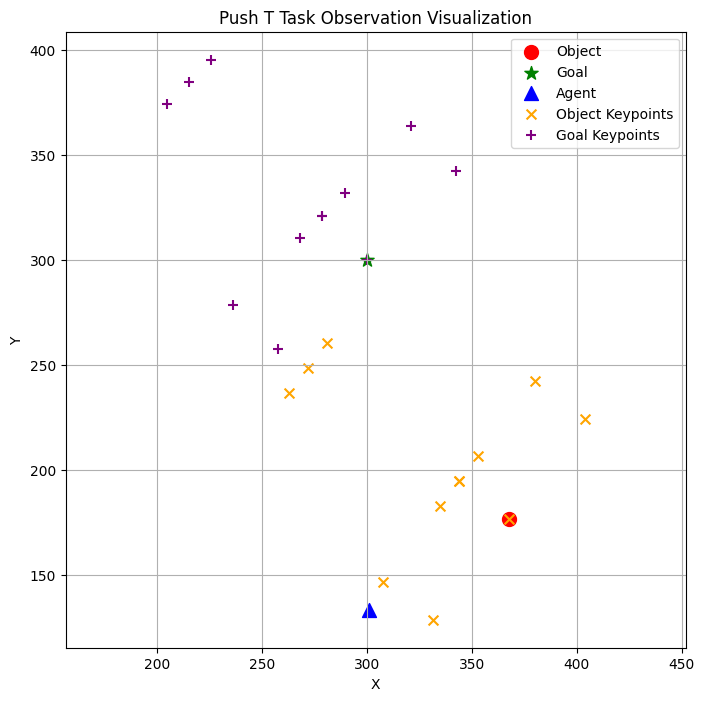

In [47]:
# Plot observation
step_num = 40
obs = demo_data[step_num]["observation"]

# Extract data
object_state = obs["object_state"]
goal_state = obs["goal_state"]
object_keypoints = obs["object_keypoints"]
goal_keypoints = obs["goal_keypoints"]
agent_pos = obs["agent_pos"]
action = demo_data[step_num]["action"]

plt.figure(figsize=(8, 8))

# Plot object position
plt.scatter(object_state[0], object_state[1], c='red', label='Object', s=100, marker='o')
# Plot goal position
plt.scatter(goal_state[0], goal_state[1], c='green', label='Goal', s=100, marker='*')
# Plot agent position
plt.scatter(agent_pos[0], agent_pos[1], c='blue', label='Agent', s=100, marker='^')

# Plot object keypoints
plt.scatter(object_keypoints[::2], object_keypoints[1::2], c='orange', label='Object Keypoints', s=50, marker='x')
# Plot goal keypoints
plt.scatter(goal_keypoints[::2], goal_keypoints[1::2], c='purple', label='Goal Keypoints', s=50, marker='+')

# Plot action point and arrow from agent_pos
# if isinstance(action, (list, np.ndarray)) and len(action) >= 2:
#     action_point = np.array(action[:2])  # action is absolute position
#     plt.scatter(action_point[0], action_point[1], c='cyan', label='Action Target', s=100, marker='s')
#     plt.arrow(agent_pos[0], agent_pos[1], action_point[0] - agent_pos[0], action_point[1] - agent_pos[1], color='cyan', width=1, head_width=2, length_includes_head=True)

plt.legend()
plt.title("Push T Task Observation Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.show()

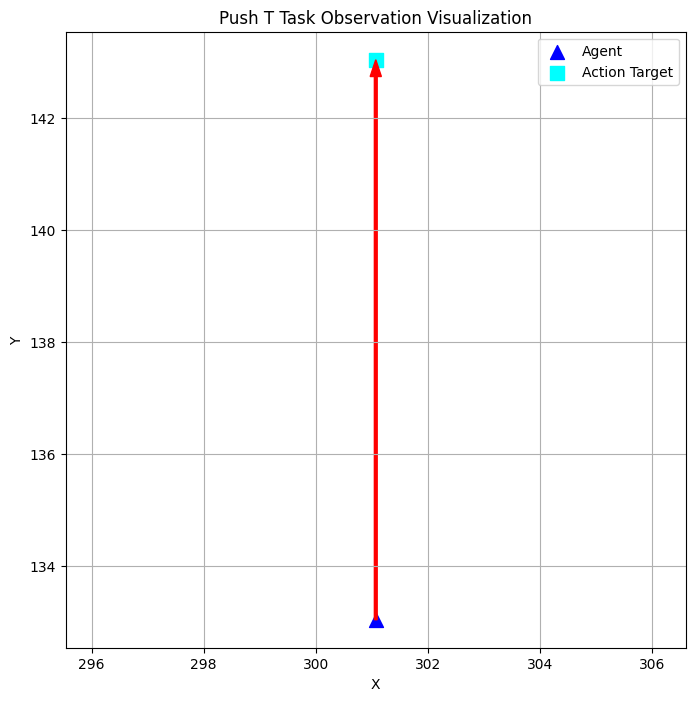

In [44]:
# Plot observation
obs = demo_data[step_num]["observation"]

# Extract data
agent_pos = obs["agent_pos"]
action = demo_data[step_num]["action"]

plt.figure(figsize=(8, 8))

# Plot agent position
plt.scatter(agent_pos[0], agent_pos[1], c='blue', label='Agent', s=100, marker='^')

# Plot action point and arrow from agent_pos
if isinstance(action, (list, np.ndarray)) and len(action) >= 2:
    action_point = np.array(action[:2])  # action is absolute position
    plt.scatter(action_point[0], action_point[1], c='cyan', label='Action Target', s=100, marker='s')
    plt.arrow(agent_pos[0], agent_pos[1], action_point[0] - agent_pos[0], action_point[1] - agent_pos[1], color='red', width=0.05, head_width=0.2, length_includes_head=True)

plt.legend()
plt.title("Push T Task Observation Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.show()

In [14]:
demo_data[0]["reward"]  

0.0

In [15]:
demo_data[0]["next_observation"]

{'object_state': array([361.        , 168.        ,   0.87084744]),
 'goal_state': array([300.        , 300.        ,   0.78539816]),
 'object_keypoints': array([322.34928431, 122.10749324, 399.65071569, 213.89250676,
        376.70446232, 233.2178646 , 299.40303093, 141.43285109,
        361.        , 168.        , 338.05374662, 187.32535785,
        328.3910677 , 175.85223116, 347.71642555, 198.79848454,
        278.87766541, 256.77455808, 259.55230756, 233.8283047 ,
        338.05374662, 187.32535785, 269.21498649, 245.30143139]),
 'goal_keypoints': array([257.57359313, 257.57359313, 342.42640687, 342.42640687,
        321.21320344, 363.63961031, 236.36038969, 278.78679656,
        300.        , 300.        , 278.78679656, 321.21320344,
        268.18019485, 310.60660172, 289.39339828, 331.81980515,
        225.75378798, 395.45941546, 204.54058454, 374.24621202,
        278.78679656, 321.21320344, 215.14718626, 384.85281374]),
 'agent_pos': array([233., 126.])}

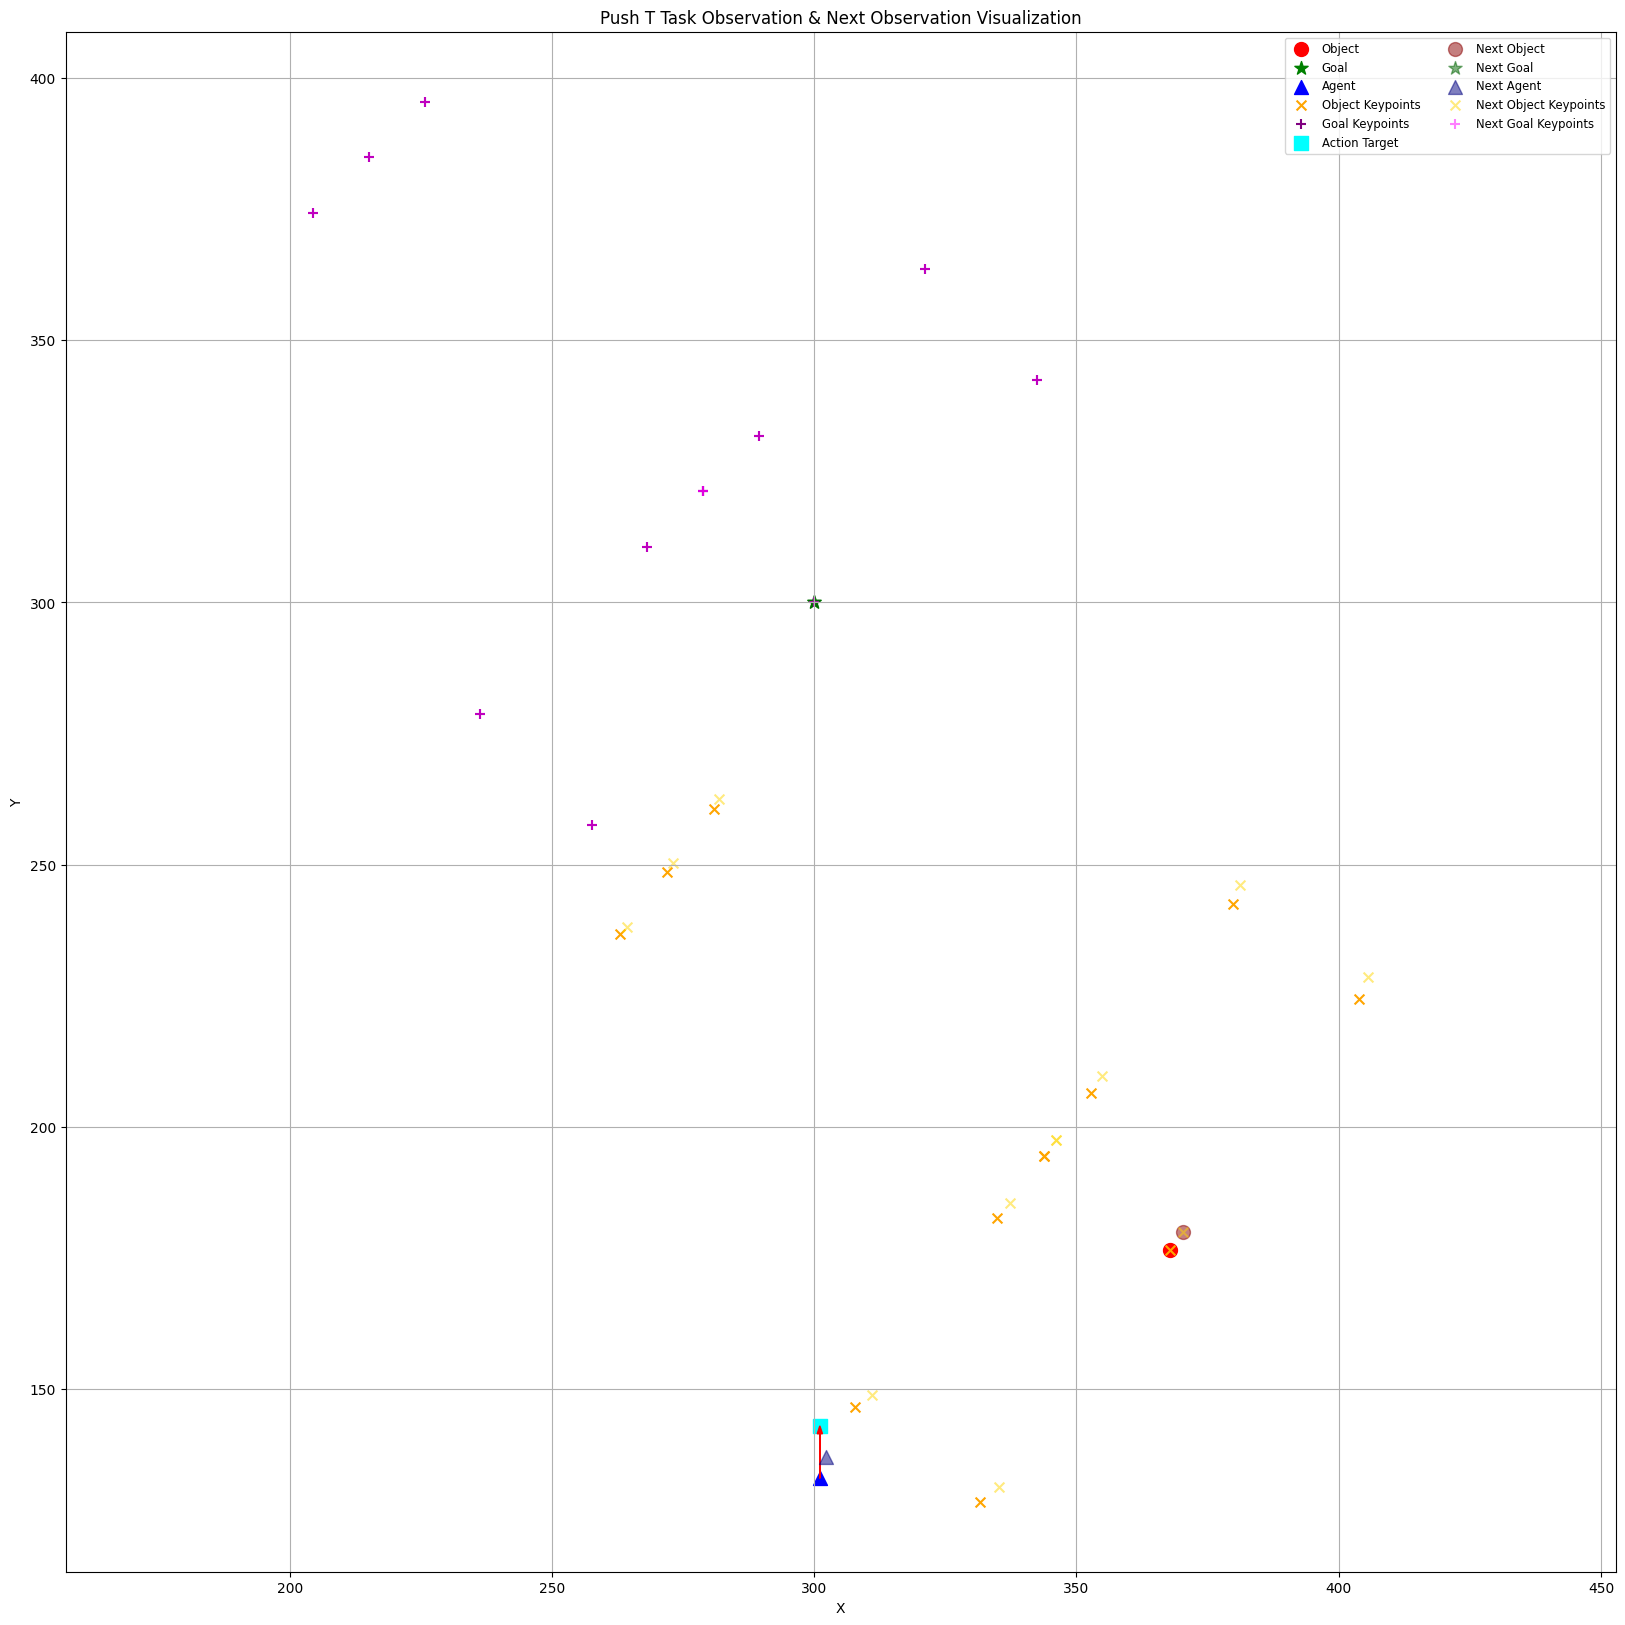

In [ ]:
# Plot observation
step_num = 40
obs = demo_data[step_num]["observation"]
next_obs = demo_data[step_num]["next_observation"]

# Extract data
object_state = obs["object_state"]
goal_state = obs["goal_state"]
object_keypoints = obs["object_keypoints"]
goal_keypoints = obs["goal_keypoints"]
agent_pos = obs["agent_pos"]
action = demo_data[step_num]["action"]

# Next observation data
next_object_state = next_obs["object_state"]
next_goal_state = next_obs["goal_state"]
next_object_keypoints = next_obs["object_keypoints"]
next_goal_keypoints = next_obs["goal_keypoints"]
next_agent_pos = next_obs["agent_pos"]

plt.figure(figsize=(20, 20))

# Plot current observation
plt.scatter(object_state[0], object_state[1], c='red', label='Object', s=100, marker='o')
plt.scatter(goal_state[0], goal_state[1], c='green', label='Goal', s=100, marker='*')
plt.scatter(agent_pos[0], agent_pos[1], c='blue', label='Agent', s=100, marker='^')
plt.scatter(object_keypoints[::2], object_keypoints[1::2], c='orange', label='Object Keypoints', s=50, marker='x')
plt.scatter(goal_keypoints[::2], goal_keypoints[1::2], c='purple', label='Goal Keypoints', s=50, marker='+')

# Plot action point and arrow from agent_pos
if isinstance(action, (list, np.ndarray)) and len(action) >= 2:
    action_point = np.array(action[:2])  # action is absolute position
    plt.scatter(action_point[0], action_point[1], c='cyan', label='Action Target', s=100, marker='s')
    plt.arrow(agent_pos[0], agent_pos[1], action_point[0] - agent_pos[0], action_point[1] - agent_pos[1], color='red', width=0.02, head_width=1, length_includes_head=True)

# Plot next observation
plt.scatter(next_object_state[0], next_object_state[1], c='darkred', label='Next Object', s=100, marker='o', alpha=0.5)
plt.scatter(next_goal_state[0], next_goal_state[1], c='darkgreen', label='Next Goal', s=100, marker='*', alpha=0.5)
plt.scatter(next_agent_pos[0], next_agent_pos[1], c='navy', label='Next Agent', s=100, marker='^', alpha=0.5)
plt.scatter(next_object_keypoints[::2], next_object_keypoints[1::2], c='gold', label='Next Object Keypoints', s=50, marker='x', alpha=0.5)
plt.scatter(next_goal_keypoints[::2], next_goal_keypoints[1::2], c='magenta', label='Next Goal Keypoints', s=50, marker='+', alpha=0.5)

plt.legend(loc='best', fontsize='small', ncol=2)
plt.title("Push T Task Observation & Next Observation Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.show()